In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = sns.load_dataset('titanic')

<h1>Basic Analysis of a Dataset</h1>

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<h1>Cleaning dataset, handling missing values</h1>

In [9]:
df_clean = df.drop(columns = ["deck"])
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])
df_clean.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [10]:
print(df_clean.shape)

(891, 14)


In [11]:
df_clean.drop_duplicates(inplace=True)
print(df_clean.shape)

(775, 14)


<h1 align = "center">Detecting and handling outliers</h1>

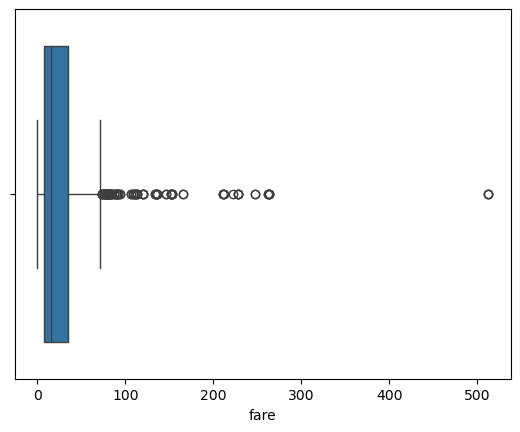

In [12]:
sns.boxplot(x=df_clean['fare'])
plt.show()

Distribution is skewed to the right, many outliers on the right side, meaning some passengers paid much higher fares than the rest, the most extreme value is around 500

In [13]:
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[

    (df_clean['fare'] >= lower_bound) &

    (df_clean['fare'] <= upper_bound)

]


26.147900000000003


# Filtering, Sorting, Aggregation

In [18]:
df_clean[(df_clean['fare']>50) & (df_clean['sex']=='female')]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
151,1,1,female,22.0,1,0,66.6000,S,First,woman,False,Southampton,yes,False
166,1,1,female,28.0,0,1,55.0000,S,First,woman,False,Southampton,yes,False
180,0,3,female,28.0,8,2,69.5500,S,Third,woman,False,Southampton,no,False
309,1,1,female,30.0,0,0,56.9292,C,First,woman,False,Cherbourg,yes,True
329,1,1,female,16.0,0,1,57.9792,C,First,woman,False,Cherbourg,yes,False
356,1,1,female,22.0,0,1,55.0000,S,First,woman,False,Southampton,yes,False
369,1,1,female,24.0,0,0,69.3000,C,First,woman,False,Cherbourg,yes,True
383,1,1,female,35.0,1,0,52.0000,S,First,woman,False,Southampton,yes,False


In [17]:
df_clean.sort_values(by='fare', ascending=False).head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,Southampton,no,False
540,1,1,female,36.0,0,2,71.0000,S,First,woman,False,Southampton,yes,False
180,0,3,female,28.0,8,2,69.5500,S,Third,woman,False,Southampton,no,False
159,0,3,male,28.0,8,2,69.5500,S,Third,man,True,Southampton,no,False


In [16]:
df_clean.groupby(by = 'class', observed=True)['fare'].mean() 

class
First     39.375186
Second    20.266300
Third     13.588850
Name: fare, dtype: float64

<h1>Visual interpretation</h1>

Text(0.5, 1.0, 'Age Distribution')

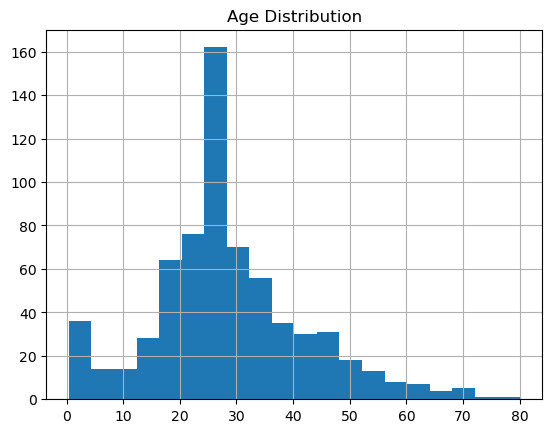

In [15]:
df_clean['age'].hist(bins=20)
plt.title('Age Distribution')

As the histogram shows, the most common age among passengers was 20–30, approximately 25. Ages 0–10 were more common than ages 60–70, which means that there were more children than elderly passengers.

Text(0.5, 1.0, 'Survival Count')

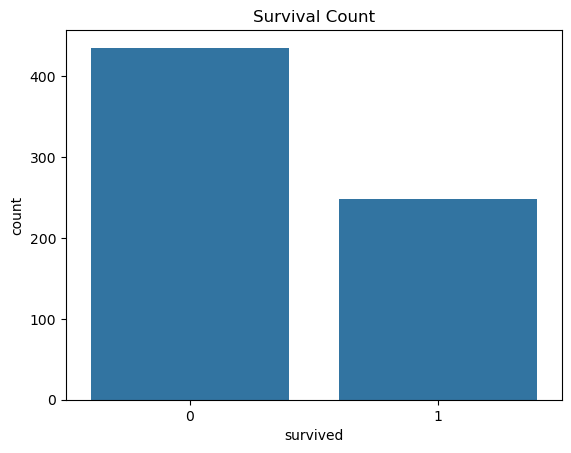

In [119]:
sns.countplot(data=df_clean, x='survived')
plt.title('Survival Count')


The majority of passengers died, and only 200–250 survived.

<Axes: >

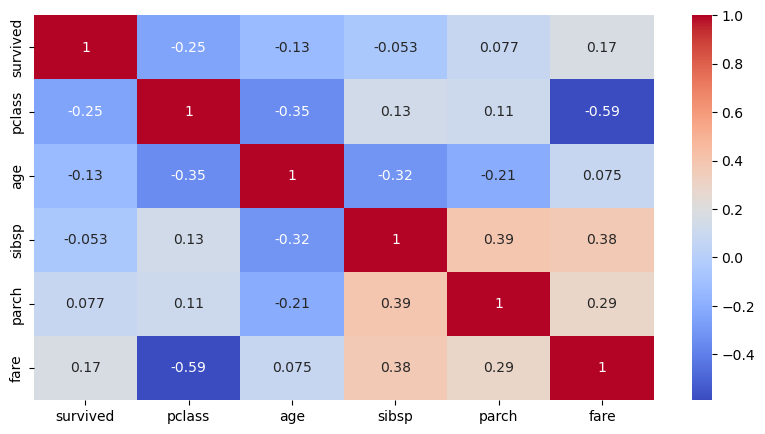

In [120]:
df_numeric = df_clean.select_dtypes(include='number')

plt.figure(figsize=(10,5))

c = df_numeric.corr()

sns.heatmap(c, cmap="coolwarm", annot=True)

We can see a high negative correlation between fare and pclass, which means that lower classes paid lower fares.

Survival and pclass have a weak correlation, so a higher class means a higher probability of survival.

Fare has a weak positive correlation with survival,  passengers with higher class were more likely to survive.

Text(0.5, 1.0, 'Survival Rate by Class and Sex')

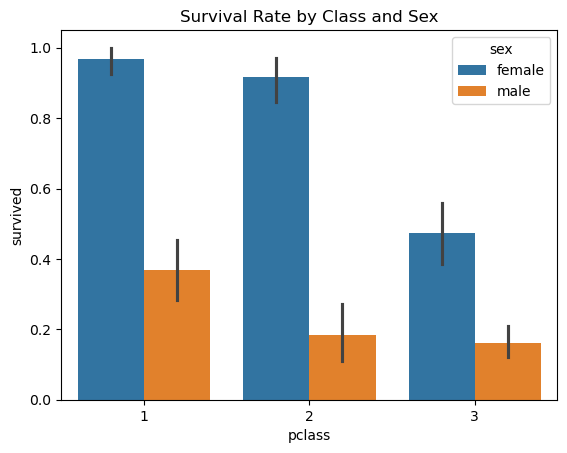

In [142]:
sns.barplot(x='pclass', y='survived', hue='sex', data=df_clean)
plt.title('Survival Rate by Class and Sex')

In each of the classes, the higher rate of survival tends to be among females. The survival rate of females is much lower by class, almost by half. The difference between the 1st and 2nd classes was not that significant.

<h1>Summary of Findings</h1>

- The dataset had missing values in $age$, $embarked$, $embark_town$, and $deck$; $deck$ was dropped for having too many missing values, and the rest were imputed.
- Outliers were removed from $fare$ using the IQR method.
- Most passengers were male, embarked from Southampton, and traveled 3rd class.
- Survival depended on $pclass$ and $sex$: 1st class and female passengers had the highest survival rates, while 3rd class males had the lowest.